In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/vyasbodke/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
df=pd.read_csv("WeatherAUS.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [5]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [6]:
df=df.drop(['Sunshine','Evaporation','Cloud9am','Cloud3pm','WindGustDir','WindDir9am','WindDir3pm'],axis=1)

removed some columns of string values as advised and other columns cause they have around 50 percent null values so median cant be filled accurately

In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,16.990631,21.68339
std,6.398495,7.119049,8.478060,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,40.200000,46.70000


found no problems with errors not matching the columns name definition or negative values like in humidity percentage is required and other values also which cant be negative

<Axes: xlabel='Rainfall'>

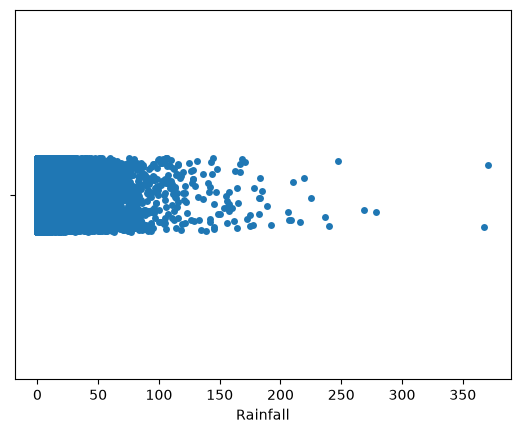

In [8]:
sns.stripplot(data=df, x="Rainfall")

will do rainfall separtely than others becuase values are not seeming right, so changing value of k as 10 instead of 1.5 experimental


In [9]:
rain=df.loc[df["Rainfall"]>0, "Rainfall"]
q1 = rain.quantile(0.25)
q3 = rain.quantile(0.75)
iqr = q3 - q1


low = q1 - 1.5* iqr
up = q3 + 10 * iqr
print("low=", low, "up=", up)

outliers = (df["Rainfall"] < low) | (df["Rainfall"] > up)

print("Rainfall values replaced:", outliers.sum())
df.loc[outliers, "Rainfall"] = np.nan

low= -9.25 up= 72.0
Rainfall values replaced: 363


<Axes: xlabel='Rainfall'>

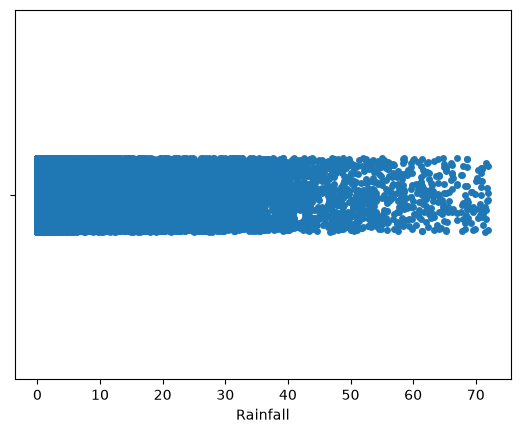

In [10]:
sns.stripplot(data=df, x="Rainfall")

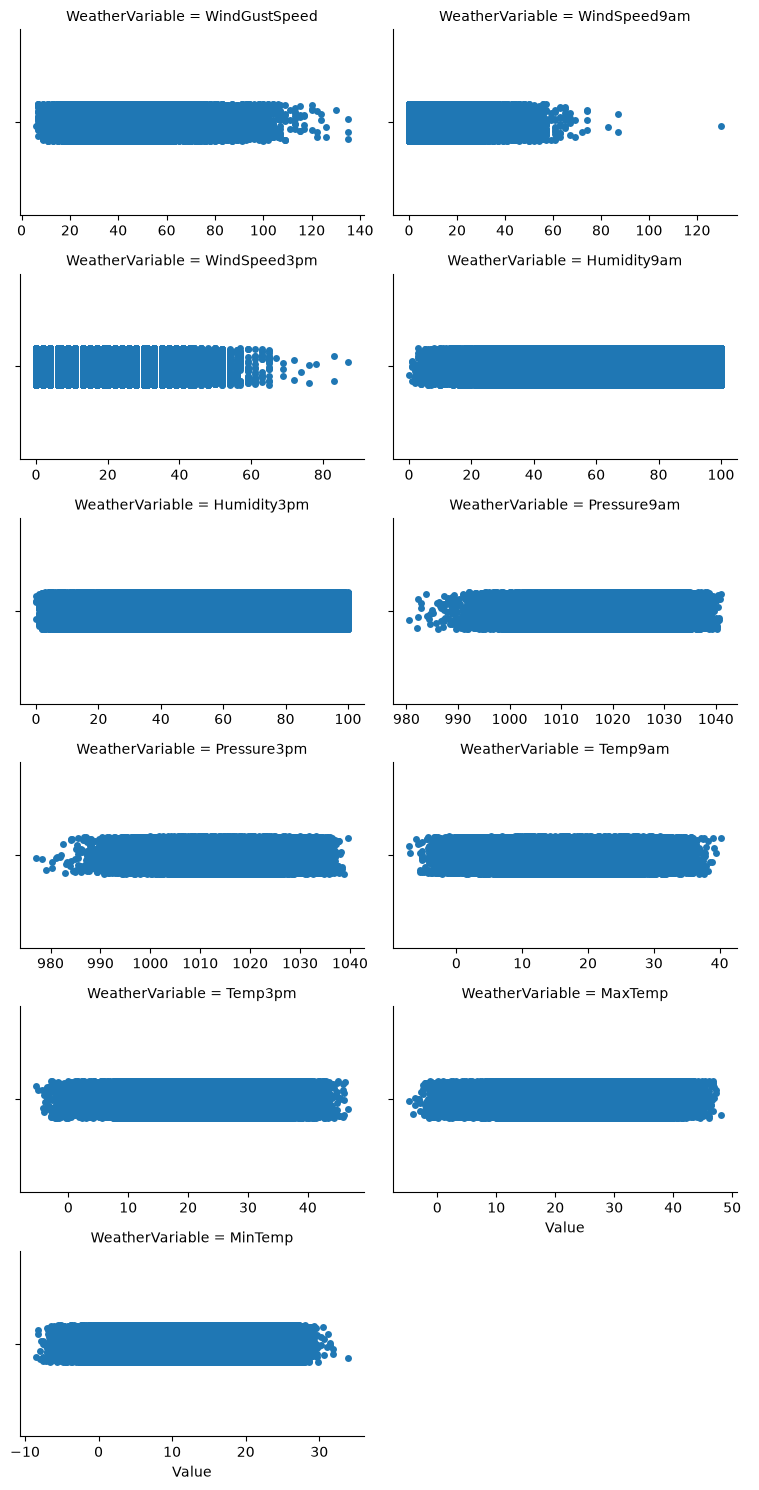

In [11]:
cols = ["WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", 
        "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", 
        "Temp9am", "Temp3pm","MaxTemp","MinTemp"]


df_melted = df.melt(value_vars=cols, var_name='WeatherVariable', value_name='Value')


sns.catplot(
    data=df_melted, 
    x='Value', 
    col='WeatherVariable', 
    col_wrap=2,      
    sharex=False, height=2.5, aspect=1.5     
    
)

plt.tight_layout()
plt.show()

In [12]:
for col in cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1

    low=q1-1.5*iqr
    up=q3+1.5*iqr
    print("low=",low,"up=",up)

    outliers=(df[col]<low)|(df[col]>up)

    print(col, "values replaced", outliers.sum())
    df.loc[outliers, col] = np.nan

low= 5.5 up= 73.5
WindGustSpeed values replaced 3092
low= -11.0 up= 37.0
WindSpeed9am values replaced 1817
low= -3.5 up= 40.5
WindSpeed3pm values replaced 2523
low= 18.0 up= 122.0
Humidity9am values replaced 1425
low= -6.5 up= 109.5
Humidity3pm values replaced 0
low= 998.65 up= 1036.65
Pressure9am values replaced 1191
low= 996.0 up= 1034.4
Pressure3pm values replaced 919
low= -1.6500000000000004 up= 35.550000000000004
Temp9am values replaced 262
low= 1.9000000000000057 up= 41.099999999999994
Temp3pm values replaced 764
low= 2.4499999999999975 up= 43.65
MaxTemp values replaced 489
low= -6.35 up= 30.849999999999998
MinTemp values replaced 54


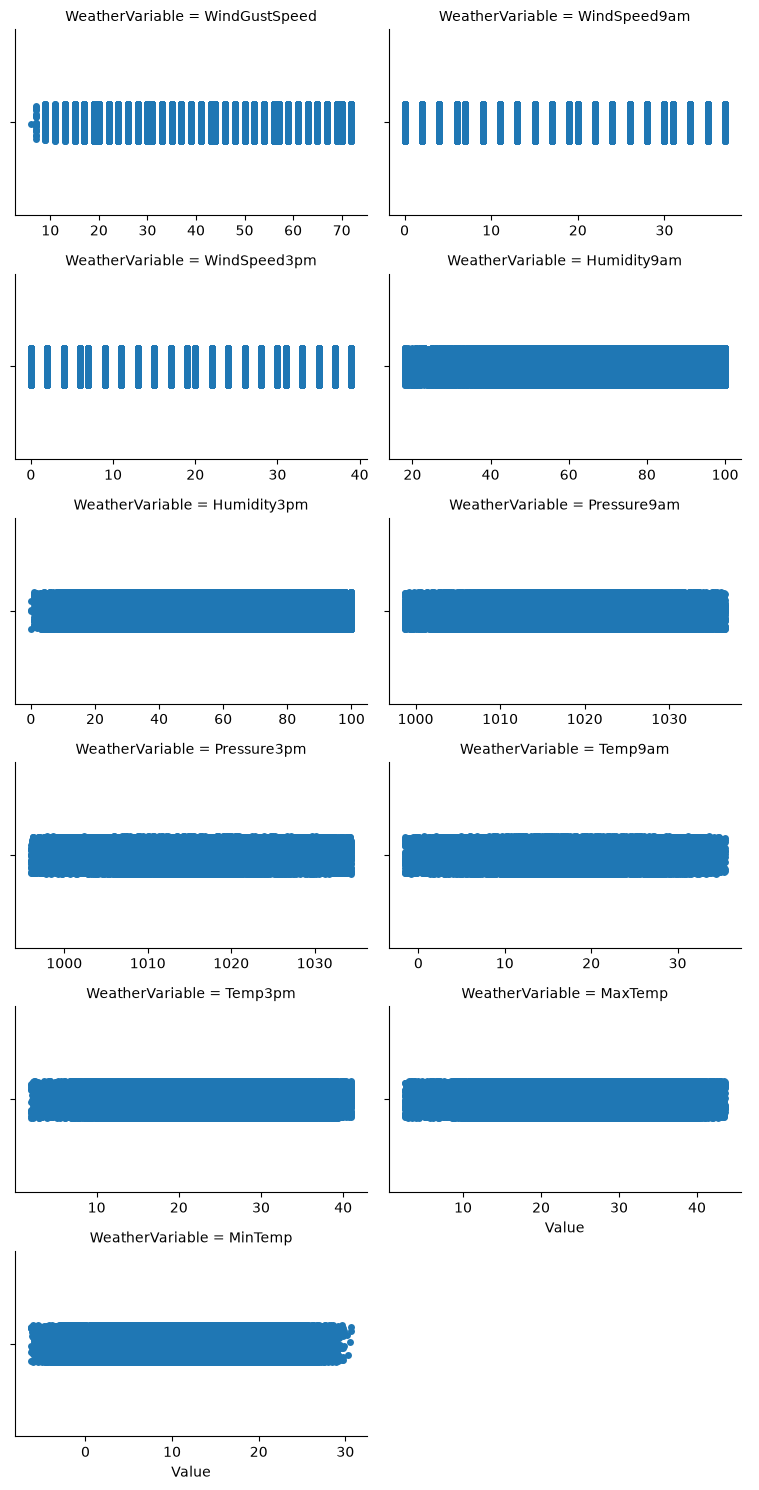

In [13]:
df_melted = df.melt(
    value_vars=cols,
    var_name="WeatherVariable",
    value_name="Value"
)
sns.catplot(
    data=df_melted, 
    x='Value', 
    col='WeatherVariable', 
    col_wrap=2,      
    sharex=False, height=2.5, aspect=1.5     
    
)

plt.tight_layout()
plt.show()

Encoding the yes no data using 1 and 0

In [14]:
mapping = {'No': 0, 'Yes': 1}

df['RainToday'] = df['RainToday'].map(mapping)
df['RainTomorrow'] = df['RainTomorrow'].map(mapping)

In [15]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1539
MaxTemp           1750
Rainfall          3624
WindGustSpeed    13355
WindSpeed9am      3584
WindSpeed3pm      5585
Humidity9am       4079
Humidity3pm       4507
Pressure9am      16256
Pressure3pm      15947
Temp9am           2029
Temp3pm           4373
RainToday         3261
RainTomorrow      3267
dtype: int64

In [16]:

rain_medians = df.groupby("RainToday")["Rainfall"].median()
print(rain_medians)


mask = df["Rainfall"].isna() & df["RainToday"].notna()

df.loc[mask, "Rainfall"] = (df.loc[mask, "RainToday"].map(rain_medians))

RainToday
0.0    0.0
1.0    5.0
Name: Rainfall, dtype: float64


Using rain today data to fill rainfall

In [17]:
mask = df["RainToday"].isna() & df["Rainfall"].notna()

df.loc[mask, "RainToday"] = (df.loc[mask, "Rainfall"] > 1).astype(int)

In [18]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1539
MaxTemp           1750
Rainfall          3261
WindGustSpeed    13355
WindSpeed9am      3584
WindSpeed3pm      5585
Humidity9am       4079
Humidity3pm       4507
Pressure9am      16256
Pressure3pm      15947
Temp9am           2029
Temp3pm           4373
RainToday         3261
RainTomorrow      3267
dtype: int64

In [19]:
df = df.dropna(subset=["RainTomorrow"]).copy()

rain_today_mode = df["RainToday"].mode()[0]
df["RainToday"] = df["RainToday"].fillna(rain_today_mode)

df["Rainfall"] = df["Rainfall"].fillna(df["RainToday"].map(rain_medians))




Using Rainfall data to fill raintoday

In [20]:
df.isnull().sum()

Date                 0
Location             0
MinTemp            690
MaxTemp            781
Rainfall             0
WindGustSpeed    12276
WindSpeed9am      3087
WindSpeed3pm      5088
Humidity9am       3193
Humidity3pm       3610
Pressure9am      15188
Pressure3pm      14887
Temp9am           1151
Temp3pm           3461
RainToday            0
RainTomorrow         0
dtype: int64

Filling normal median as no more relations I can find

In [21]:
df[cols] = df[cols].fillna(df[cols].median())

df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [22]:
df = pd.get_dummies(df, columns=["Location"],dtype=int)

Encoding Location data here

In [23]:
df.filter(like="Location_").head(25)

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df["Date"] = pd.to_datetime(df["Date"])

dates = df["Date"].sort_values().unique()
cutoff = dates[int(len(dates) * 0.8)]

train = df.loc[df["Date"] < cutoff].copy()
test = df.loc[df["Date"] >= cutoff].copy()

X_train = train.drop(columns=["Date", "RainTomorrow"])
X_test = test.drop(columns=["Date", "RainTomorrow"])

y_train = train["RainTomorrow"]
y_test = test["RainTomorrow"]

Splitting the data before scaling as per site kaggle

In [25]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    "MinTemp", "MaxTemp", "Rainfall",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "Temp9am", "Temp3pm"
]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

Scaling data as per kaggle site

In [26]:
X_train[scale_cols].agg(["mean", "std"]).round(2)

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
mean,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


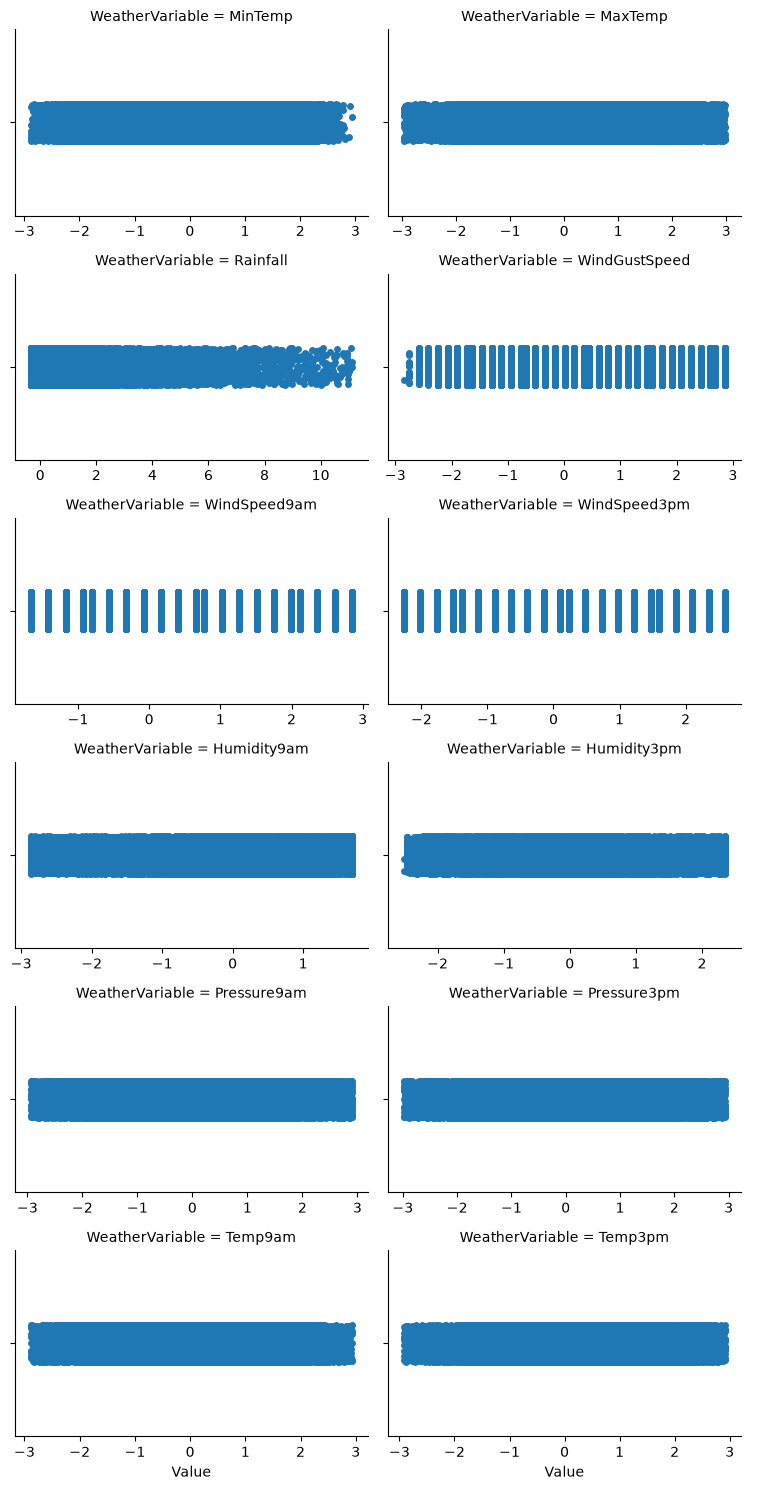

In [27]:

df_melted = X_train.melt(
    value_vars=scale_cols,
    var_name="WeatherVariable",
    value_name="Value"
)


sns.catplot(
    data=df_melted, 
    x='Value', 
    col='WeatherVariable', 
    col_wrap=2,      
    sharex=False, height=2.5, aspect=1.5     
    
)

plt.tight_layout()
plt.show()